<a href="https://colab.research.google.com/github/khushisood007/ABC/blob/main/pruning_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Device: cuda


100%|██████████| 170M/170M [00:04<00:00, 41.0MB/s]


TRAINING WITH LAMBDA = 0.001
Epoch [1/20] Loss: 730.20 Accuracy: 42.64%
Epoch [2/20] Loss: 655.03 Accuracy: 44.61%
Epoch [3/20] Loss: 626.57 Accuracy: 48.05%
Epoch [4/20] Loss: 609.46 Accuracy: 49.59%
Epoch [5/20] Loss: 594.58 Accuracy: 50.26%
Epoch [6/20] Loss: 584.67 Accuracy: 51.89%
Epoch [7/20] Loss: 572.82 Accuracy: 51.96%
Epoch [8/20] Loss: 564.84 Accuracy: 52.62%
Epoch [9/20] Loss: 556.74 Accuracy: 53.31%
Epoch [10/20] Loss: 551.53 Accuracy: 53.93%
Epoch [11/20] Loss: 543.38 Accuracy: 54.01%
Epoch [12/20] Loss: 537.27 Accuracy: 55.77%
Epoch [13/20] Loss: 530.35 Accuracy: 55.99%
Epoch [14/20] Loss: 526.57 Accuracy: 56.76%
Epoch [15/20] Loss: 521.55 Accuracy: 56.81%
Epoch [16/20] Loss: 516.41 Accuracy: 56.89%
Epoch [17/20] Loss: 514.65 Accuracy: 57.43%
Epoch [18/20] Loss: 509.41 Accuracy: 57.20%
Epoch [19/20] Loss: 511.75 Accuracy: 57.23%
Epoch [20/20] Loss: 510.71 Accuracy: 57.37%

FINAL RESULTS
Accuracy: 57.37%
Sparsity: 17.66%
TRAINING WITH LAMBDA = 0.005
Epoch [1/20] Loss: 729

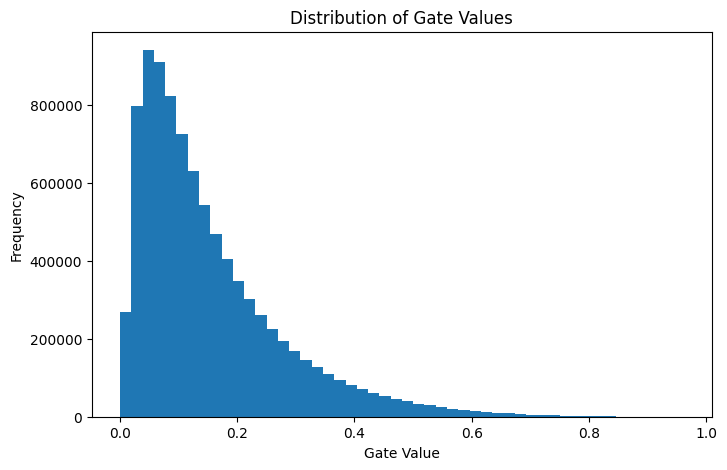

BEST MODEL
Best Accuracy: 57.63%
Best Sparsity: 17.68%


In [1]:


# INSTALLS

!pip install torch torchvision matplotlib -q

# IMPORTS

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

# DEVICE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)


# CUSTOM PRUNABLE LAYER

class PrunableLinear(nn.Module):

    def __init__(self, in_features, out_features):
        super().__init__()

        # Learnable weights
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * 0.02
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

        # Learnable gate scores
        # Initialized negatively so pruning starts easier
        self.gate_scores = nn.Parameter(
            torch.randn(out_features, in_features) - 2
        )

    def forward(self, x):

        # Convert gate scores → [0,1]
        gates = torch.sigmoid(self.gate_scores)

        # Element-wise pruning
        pruned_weights = self.weight * gates

        return F.linear(x, pruned_weights, self.bias)


# MODEL

class SelfPruningNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(3072, 2048)
        self.bn1 = nn.BatchNorm1d(2048)

        self.fc2 = PrunableLinear(2048, 1024)
        self.bn2 = nn.BatchNorm1d(1024)

        self.fc3 = PrunableLinear(1024, 512)
        self.bn3 = nn.BatchNorm1d(512)

        self.fc4 = PrunableLinear(512, 256)
        self.bn4 = nn.BatchNorm1d(256)

        self.fc5 = PrunableLinear(256, 10)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):

        # Flatten image
        x = x.view(x.size(0), -1)

        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout(x)

        x = F.relu(self.bn4(self.fc4(x)))
        x = self.dropout(x)

        x = self.fc5(x)

        return x

# DATA AUGMENTATION

train_transform = transforms.Compose([

    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

# DATASET

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2
)

# SPARSITY LOSS

def sparsity_loss(model):

    total_loss = 0
    total_params = 0

    for module in model.modules():

        if isinstance(module, PrunableLinear):

            gates = torch.sigmoid(module.gate_scores)

            # L1 regularization
            total_loss += torch.sum(torch.abs(gates))

            total_params += gates.numel()

    # Normalize
    return total_loss / total_params

# ACCURACY FUNCTION

def evaluate(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# SPARSITY CALCULATION

def calculate_sparsity(model, threshold=0.05):

    total = 0
    pruned = 0

    for module in model.modules():

        if isinstance(module, PrunableLinear):

            gates = torch.sigmoid(module.gate_scores)

            total += gates.numel()

            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

# TRAINING CONFIG

lambdas = [0.001, 0.005, 0.01]

results = []

best_model = None
best_accuracy = 0

# TRAINING LOOP

for lambda_sparse in lambdas:


    print(f"TRAINING WITH LAMBDA = {lambda_sparse}")


    model = SelfPruningNet().to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=20
    )

    epochs = 20

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            ce_loss = F.cross_entropy(outputs, labels)

            sp_loss = sparsity_loss(model)

            loss = ce_loss + lambda_sparse * sp_loss

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        accuracy = evaluate(model)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {running_loss:.2f} "
            f"Accuracy: {accuracy:.2f}%"
        )

    # Final Metrics
    final_accuracy = evaluate(model)

    sparsity = calculate_sparsity(model)

    print("\nFINAL RESULTS")
    print(f"Accuracy: {final_accuracy:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")

    results.append(
        (lambda_sparse, final_accuracy, sparsity)
    )

    # Save best model
    if final_accuracy > best_accuracy:

        best_accuracy = final_accuracy

        best_model = model


# FINAL RESULTS TABLE


print("FINAL COMPARISON")

for l, acc, sp in results:

    print(
        f"Lambda: {l} | "
        f"Accuracy: {acc:.2f}% | "
        f"Sparsity: {sp:.2f}%"
    )

# GATE DISTRIBUTION PLOT

all_gates = []

for module in best_model.modules():

    if isinstance(module, PrunableLinear):

        gates = torch.sigmoid(
            module.gate_scores
        ).detach().cpu().numpy()

        all_gates.extend(gates.flatten())

plt.figure(figsize=(8,5))

plt.hist(all_gates, bins=50)

plt.title("Distribution of Gate Values")

plt.xlabel("Gate Value")

plt.ylabel("Frequency")

plt.show()

# FINAL BEST METRICS


print("BEST MODEL")


print(f"Best Accuracy: {best_accuracy:.2f}%")

best_sparsity = calculate_sparsity(best_model)

print(f"Best Sparsity: {best_sparsity:.2f}%")